# Titanic Sample Project — End-to-End Classroom Solution

In [ ]:
# Import libraries we need for data analysis and machine learning
import pandas as pd              # For working with data tables (like Excel)  # pandas: tables and CSVs
import numpy as np               # For mathematical calculations  # numpy: math and arrays
import matplotlib.pyplot as plt  # For creating charts and graphs  # matplotlib: charts (basic plotting)

# Import tools for machine learning
from sklearn.model_selection import train_test_split     # Splits data into training and testing sets  # tool to split data into train/validation sets
from sklearn.linear_model import LogisticRegression      # A simple machine learning algorithm  # a simple, strong baseline model for classification
from sklearn.ensemble import RandomForestClassifier      # A more advanced machine learning algorithm  # tree-based model that handles non-linear patterns well

# Import tools to measure how well our models perform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  # metrics to measure model quality

# Import tools to prepare our data for machine learning
from sklearn.preprocessing import OneHotEncoder  # Converts text categories to numbers  # turn categories into 0/1 columns
from sklearn.compose import ColumnTransformer   # Applies different preparations to different columns  # apply different preprocessing to numeric vs categorical
from sklearn.pipeline import Pipeline           # Chains multiple steps together  # chain preprocessing and model into one object
from sklearn.impute import SimpleImputer        # Fills in missing data values  # fill in missing values
from sklearn.inspection import permutation_importance  # Shows which features are most important  # explain which features matter by shuffling them

# Set the default size for all our charts
plt.rcParams['figure.figsize'] = (7, 5)  # step in the pipeline


### Result guide
**What this shows:** A baseline Logistic Regression model’s metrics (Accuracy, Precision, Recall, F1) and a confusion matrix. Focus on Recall (how many survivors we caught) and Precision (how many predicted survivors were correct).

In [5]:
url = "https://raw.githubusercontent.com/duochen/data-science-bootcamp/refs/heads/main/StudentProjects/Sample%20Projects/Titanic/titanic_train.csv"  # step in the pipeline
df = pd.read_csv(url);   # load the Titanic-like CSV into a DataFrame
print("Shape:", df.shape);   # step in the pipeline

df.head()  # peek at the first few rows to confirm columns look right


Shape: (220, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,Mr. Passenger_0,male,34.515249,0,0,46781,35.650621,C146,S
1,0,3,Mr. Passenger_1,male,9.852788,0,0,93388,14.882798,NaN,S
2,1,2,Mrs. Passenger_2,female,35.470175,0,0,34606,18.412752,NaN,S
3,0,3,Mr. Passenger_3,male,9.823095,0,0,90180,6.529317,NaN,S
4,1,3,Mrs. Passenger_4,female,28.611071,0,0,25730,12.923017,NaN,S


### Result guide
**What this shows:** You loaded the data table from CSV and previewed the first rows. You should see familiar Titanic-style columns like Sex, Age, and Survived. If the file path is wrong, you’ll get a FileNotFoundError.

In [6]:
print(df.dtypes);   # show column data types
print("\nMissing values:");   # step in the pipeline
print(df.isna().sum());   # count missing values per column
print("\nTarget:");   # step in the pipeline
print(df['Survived'].value_counts(normalize=True).round(3))  # check class balance (what % survived)


Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket        int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

Missing values:
Survived      0
Pclass        0
Name          0
Sex           0
Age          43
SibSp         0
Parch         0
Ticket        0
Fare          6
Cabin       183
Embarked      0
dtype: int64

Target:
Survived
1    0.573
0    0.427
Name: proportion, dtype: float64


### Result guide
**What this shows:** Data types (number vs text) and how many values are missing per column. This helps you choose imputation strategies. You’ll also see what fraction of passengers survived.

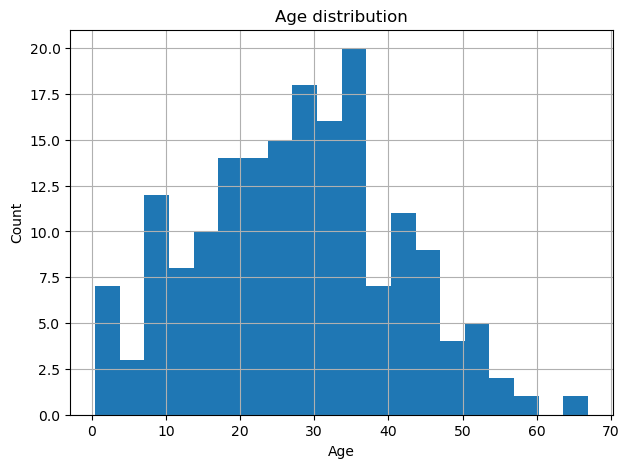

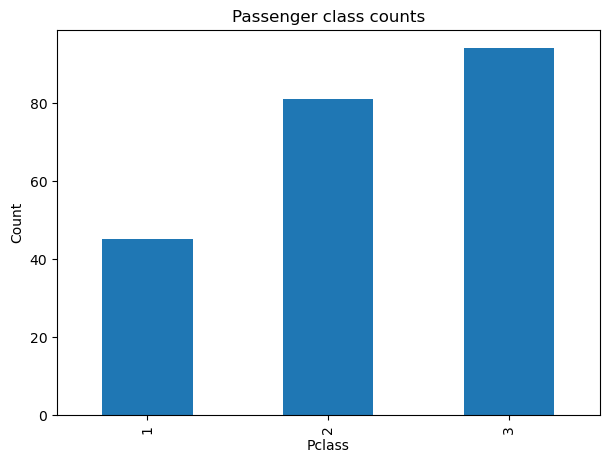

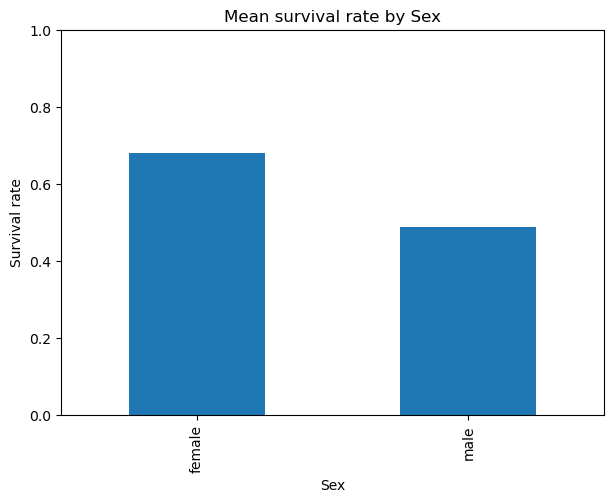

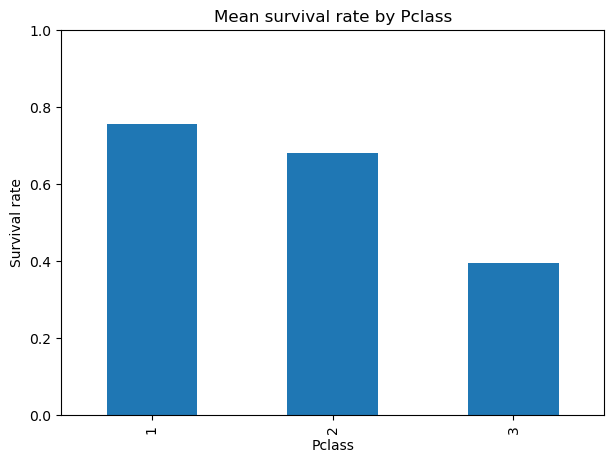

In [4]:
df['Age'].dropna().hist(bins=20);   # histogram of ages (shape of age distribution)
plt.title('Age distribution');   # step in the pipeline
plt.xlabel('Age');   # step in the pipeline
plt.ylabel('Count');   # step in the pipeline
plt.show()  # step in the pipeline

df['Pclass'].value_counts().sort_index().plot(kind='bar');   # bar chart of passenger classes (1st, 2nd, 3rd)
plt.title('Passenger class counts');   # step in the pipeline
plt.xlabel('Pclass');   # step in the pipeline
plt.ylabel('Count');   # step in the pipeline
plt.show()  # step in the pipeline

df.groupby('Sex')['Survived'].mean().plot(kind='bar');   # survival rate by Sex (average of 0/1)
plt.title('Mean survival rate by Sex');   # step in the pipeline
plt.xlabel('Sex');   # step in the pipeline
plt.ylabel('Survival rate');   # step in the pipeline
plt.ylim(0,1);   # step in the pipeline
plt.show()  # step in the pipeline

df.groupby('Pclass')['Survived'].mean().plot(kind='bar');   # survival rate by Pclass (1,2,3)
plt.title('Mean survival rate by Pclass');   # step in the pipeline
plt.xlabel('Pclass');   # step in the pipeline
plt.ylabel('Survival rate');   # step in the pipeline
plt.ylim(0,1);   # step in the pipeline
plt.show()  # step in the pipeline


### Result guide
**What this shows:** Basic patterns. Ages are usually centered around young adults; survival is typically higher for females and for 1st class. These patterns hint that Sex and Pclass will be important features.

Acc 0.6545454545454545 Prec 0.6578947368421053 Rec 0.8064516129032258 F1 0.7246376811594203
              precision    recall  f1-score   support

           0      0.647     0.458     0.537        24
           1      0.658     0.806     0.725        31

    accuracy                          0.655        55
   macro avg      0.652     0.632     0.631        55
weighted avg      0.653     0.655     0.643        55

[[11 13]
 [ 6 25]]


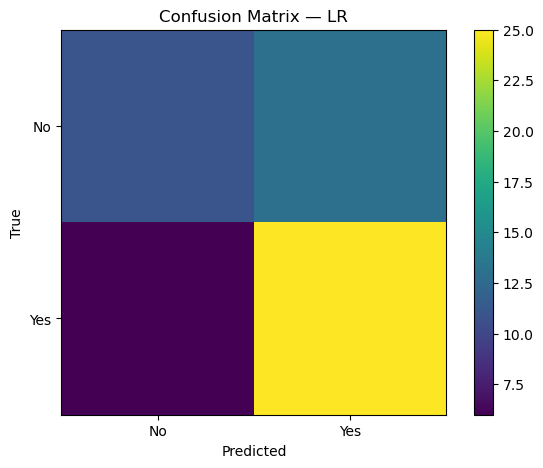

In [7]:
FEATURES=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'];   # pick helpful columns for the model (drop IDs like Name/Ticket)
TARGET='Survived'  # label we want to predict (0 = no survive, 1 = survive)

X=df[FEATURES].copy();   # features (inputs)
y=df[TARGET].copy()  # target (output)

num=['Age','SibSp','Parch','Fare'];   # numeric columns to impute with median
cat=['Pclass','Sex','Embarked']  # categorical columns to impute and one‑hot encode

pre=ColumnTransformer([('num',SimpleImputer(strategy='median'),num),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)])  # apply different preprocessing to numeric vs categorical
Xtr,Xva,Ytr,Yva=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)  # split into training/validation sets (keep class ratio with stratify)

lr=Pipeline([('prep',pre),('clf',LogisticRegression(max_iter=1000))]).fit(Xtr,Ytr)  # baseline model pipeline: preprocess + Logistic Regression
pred_lr=lr.predict(Xva)  # make predictions on validation set

def evalm(y_true,y_hat):  # helper function to print common metrics nicely
    print("Acc",accuracy_score(y_true,y_hat),"Prec",precision_score(y_true,y_hat),"Rec",recall_score(y_true,y_hat),"F1",f1_score(y_true,y_hat))  # step in the pipeline
    print(classification_report(y_true,y_hat,digits=3))  # step in the pipeline

evalm(Yva,pred_lr)  # evaluate baseline performance
cm=confusion_matrix(Yva,pred_lr); print(cm)  # confusion matrix: counts of correct/incorrect predictions

plt.imshow(cm,interpolation='nearest');   # visualize confusion matrix as a heatmap
plt.title('Confusion Matrix — LR');   # step in the pipeline
plt.colorbar();   # step in the pipeline
plt.xticks([0,1],['No','Yes']);   # step in the pipeline
plt.yticks([0,1],['No','Yes']);   # step in the pipeline
plt.xlabel('Predicted');   # step in the pipeline
plt.ylabel('True');   # step in the pipeline
plt.show()  # step in the pipeline


### Result guide
**What this shows:** A baseline Logistic Regression model’s metrics (Accuracy, Precision, Recall, F1) and a confusion matrix. Focus on Recall (how many survivors we caught) and Precision (how many predicted survivors were correct).

Acc 0.6181818181818182 Prec 0.6388888888888888 Rec 0.7419354838709677 F1 0.6865671641791045
              precision    recall  f1-score   support

           0      0.579     0.458     0.512        24
           1      0.639     0.742     0.687        31

    accuracy                          0.618        55
   macro avg      0.609     0.600     0.599        55
weighted avg      0.613     0.618     0.610        55

[[11 13]
 [ 8 23]]


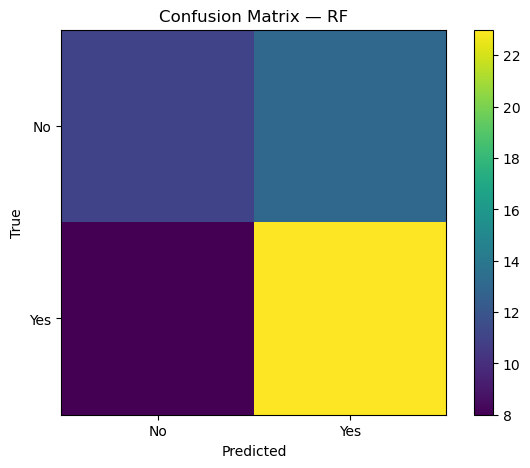

In [8]:
rf=Pipeline([('prep',pre),('clf',RandomForestClassifier(n_estimators=300,random_state=42))]).fit(Xtr,Ytr)  # stronger model pipeline: preprocess + Random Forest (300 trees)
pred_rf=rf.predict(Xva)  # predictions from Random Forest on validation set
evalm(Yva,pred_rf)  # evaluate Random Forest performance
cm2=confusion_matrix(Yva,pred_rf);   # confusion matrix for Random Forest
print(cm2)  # step in the pipeline

plt.imshow(cm2,interpolation='nearest');   # visualize confusion matrix as a heatmap
plt.title('Confusion Matrix — RF');   # step in the pipeline
plt.colorbar();  # step in the pipeline
plt.xticks([0,1],['No','Yes']);   # step in the pipeline
plt.yticks([0,1],['No','Yes']);   # step in the pipeline
plt.xlabel('Predicted');   # step in the pipeline
plt.ylabel('True');   # step in the pipeline
plt.show()  # step in the pipeline


### Result guide
**What this shows:** Random Forest performance, often better than the baseline. Compare both models’ F1 scores and confusion matrices to decide which is stronger.

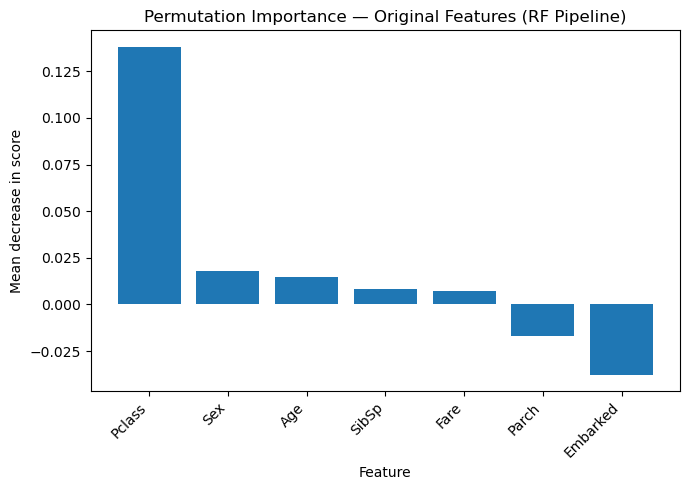

In [10]:
# Use the pipeline directly: importance is computed over original input columns
base_features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']  # step in the pipeline

r = permutation_importance(  # explain which features matter by shuffling them
    rf,                  # the Pipeline  # step in the pipeline
    Xva[base_features],  # original features as seen by the pipeline  # step in the pipeline
    Yva,  # step in the pipeline
    n_repeats=15,  # step in the pipeline
    random_state=42  # step in the pipeline
)  # step in the pipeline

idx = np.argsort(r.importances_mean)[::-1]  # step in the pipeline
k = min(7, len(base_features))  # there are 7 original columns  # step in the pipeline

plt.bar(range(k), r.importances_mean[idx][:k])  # step in the pipeline
plt.xticks(range(k), np.array(base_features)[idx][:k], rotation=45, ha='right')  # step in the pipeline
plt.title('Permutation Importance — Original Features (RF Pipeline)')  # step in the pipeline
plt.xlabel('Feature')  # step in the pipeline
plt.ylabel('Mean decrease in score')  # bar chart of top feature importances
plt.tight_layout()  # step in the pipeline
plt.show()  # step in the pipeline


### Result guide
**What this shows:** Which features affect predictions most on the validation set. Expect Sex and Pclass near the top. Bars farther right (larger values) mean greater importance.

**Takeaways:** Sex and Pclass usually dominate; RF often outperforms LR; always validate and examine errors.